# Задача регрессии (self implementation)

In [10]:
# Импортируем необходимые библиотеки
import numpy as np  # для численных вычислений
import pandas as pd  # для работы с табличными данными
from sklearn.model_selection import train_test_split  # для разделения данных на обучающую и тестовую выборку
import matplotlib.pyplot as plt  # для визуализации

In [11]:
# Создадим класс линейной регрессии,
# который будет содержать ключевые методы для решения задачи:
# - конструктор класса;
# - метод обучения алгоритма;
# - метод пересчета весов;
# - метод, делающий предсказания на основе найденного уравнения.
class LinearRegression:
    """
    Класс реализует модель линейной регрессии,
    обучаемую методом градиентного спуска.

    Модель имеет вид:
        y = Xw + b

    где:
        w — вектор весов,
        b — смещение (bias).
    """

    def __init__(self, learning_rate: float = 0.01, iterations: int = 1000):
        """
        Используется для инициализации параметров класса.

        :param learning_rate: скорость обучения (шаг градиентного спуска).
        :param iterations: количество итераций обучения модели.
        """
        self.learning_rate = float(learning_rate)
        self.iterations = int(iterations)

        # Параметры модели
        self.weights: np.ndarray | None = None
        self.bias: float = 0.0

        # Данные, используемые в процессе обучения
        self.X: np.ndarray | None = None
        self.Y: np.ndarray | None = None

        # История значения функции потерь
        self.loss_history: list[float] = []

    def fit(self, X, Y):
        """
        Метод обучает модель линейной регрессии.

        Задача — на основе входных данных X и целевой переменной Y
        найти оптимальные веса и смещение, минимизируя функцию потерь (MSE).

        Алгоритм:
            1. Инициализация весов и смещения.
            2. Повторение заданного числа итераций:
                - вычисление предсказаний,
                - вычисление ошибки,
                - обновление параметров методом градиентного спуска.

        :param X: матрица признаков формы (m, n),
                  где m — количество объектов,
                  n — количество признаков.
        :param Y: вектор целевых значений формы (m,).
        :return: обученный объект модели.
        """
        X = np.asarray(X, dtype=float)
        Y = np.asarray(Y, dtype=float).reshape(-1)

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        m, n = X.shape

        # Инициализация параметров
        self.weights = np.zeros(n)
        self.bias = 0.0

        self.X = X
        self.Y = Y

        for _ in range(self.iterations):
            self.update_weights()

            # Сохраняем значение ошибки (MSE)
            predictions = self.predict(X)
            loss = np.mean((Y - predictions) ** 2)
            self.loss_history.append(loss)

        return self

    def update_weights(self):
        """
        Выполняет один шаг градиентного спуска.

        Вычисляет:
            - градиент функции потерь по весам,
            - градиент по смещению,

        Затем обновляет параметры модели.

        Формулы для MSE:

            dW = (-2/m) * X^T (Y - Y_pred)
            db = (-2/m) * sum(Y - Y_pred)

        где:
            m — количество объектов.
        """
        if self.X is None or self.Y is None or self.weights is None:
            raise ValueError("Модель не обучена. Сначала вызовите fit().")

        X = self.X
        Y = self.Y
        m = X.shape[0]

        predictions = X @ self.weights + self.bias
        error = Y - predictions

        dW = (-2.0 / m) * (X.T @ error)
        db = (-2.0 / m) * np.sum(error)

        self.weights -= self.learning_rate * dW
        self.bias -= self.learning_rate * db

        return self.weights, self.bias

    def predict(self, X):
        """
        Используется для предсказания значений на основе обученной модели.

        Применяет формулу линейной регрессии:
            y = Xw + b

        :param X: матрица признаков формы (m, n)
                  или вектор формы (m,)
        :return: вектор предсказанных значений формы (m,)
        """
        if self.weights is None:
            raise ValueError("Модель не обучена. Сначала вызовите fit().")

        X = np.asarray(X, dtype=float)

        if X.ndim == 1:
            X = X.reshape(-1, 1)

        return X @ self.weights + self.bias

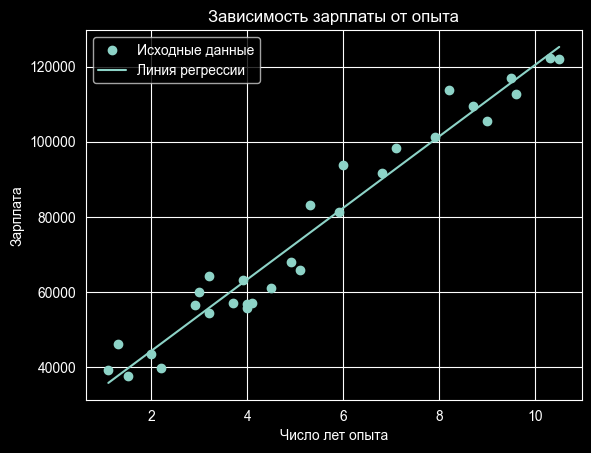

In [12]:
# Пример кода со считыванием и подготовкой данных для обучения,
# а также использование класса линейной регрессии для обучения.
df = pd.read_csv("input_data/salary_data.csv")

X = df.iloc[:, :-1].values  # признаки
Y = df.iloc[:, 1].values    # цель

model = LinearRegression(iterations=1000, learning_rate=0.01)
model.fit(X, Y)

Y_pred = model.predict(X)

plt.scatter(X, Y, label="Исходные данные")
plt.plot(X, Y_pred, label="Линия регрессии")
plt.title("Зависимость зарплаты от опыта")
plt.xlabel("Число лет опыта")
plt.ylabel("Зарплата")
plt.legend()
plt.show()

📊1️⃣График "Зависимость зарплаты от опыта"

Что мы видим:
- Голубые точки — реальные данные.
- Линия — предсказания модели.
- Линия хорошо проходит через центр облака точек.

Интерпретация:
1. Наблюдается четкая линейная зависимость:
- зарплата растет примерно линейно с увеличением опыта.
2. Линия регрессии:
- не слишком крутая
- не слишком плоская
- проходит примерно посередине точек

Это означает:
1. Модель хорошо уловила общий тренд.

Что можно сказать про качество:
1. Нет явной недообученности (линия не "мимо" данных)
2. Нет переобучения (линия не повторяет шум)
3. Ошибки выглядят примерно равномерными
4. Визуально — хорошая аппроксимация.

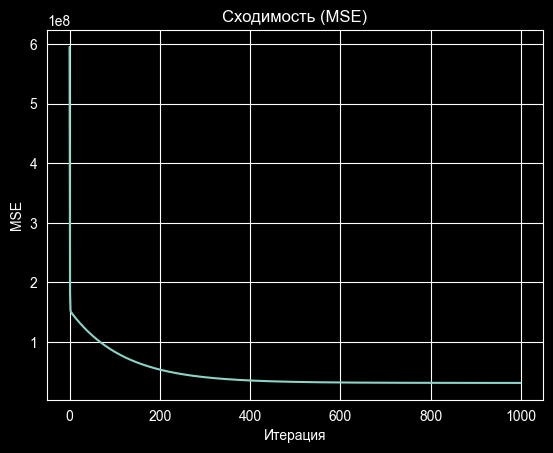

In [13]:
# График сходимости
plt.plot(model.loss_history)
plt.title("Сходимость (MSE)")
plt.xlabel("Итерация")
plt.ylabel("MSE")
plt.show()

📉2️⃣График "Сходимость (MSE)"

Это самый интересный график с точки зрения ML.

Что происходит:
1. В начале ошибка огромная (~6e8)
2. Затем она резко падает
3. Потом снижение замедляется
4. В конце кривая выходит на плато

🔎 Что это значит

🔹 Резкое падение в начале
Модель быстро находит направление правильного минимума.
Это нормальное поведение градиентного спуска.

🔹 Плавное замедление
Когда мы приближаемся к минимуму, градиенты становятся меньше.
Шаги становятся «тонкими».

🔹 Плато
Это означает:
Модель сошлась.

Дальнейшие итерации почти ничего не меняют.